
# Datan alkuperä

Latasin Breast Cancer Wisconsin (Diagnostic) -aineiston UCI Machine Learning Repositorysta.

## Datan kuvaus

Aineisto sisältää 569 rintakasvaimen ohutneulanäytettä. Jokaisesta näytteestä on 30 solutumien ominaisuuksia kuvaavaa muuttujaa sekä diagnoosi (hyvän- tai pahanlaatuinen).


UCI Machine Learning Repository – Breast Cancer Wisconsin (Diagnostic) 

In [33]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
import numpy as np

In [34]:

dataset = load_breast_cancer(as_frame=True)

X = dataset.data
y = (dataset.target == 0).astype(int)
y.name = "malignant"

df = pd.concat([X, y], axis=1)

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [35]:
# Const values 
DATA_PATH = Path("Breast_cancer_project") / "data"
TRAINING_PATH = DATA_PATH / "training_dataset.csv"
TEST_PATH = DATA_PATH / "test_dataset.csv"

TRAINING_DATA_SIZE = 0.75
RANDOM_SEED = 42



CORRELATION_THRESHOLD = 0.90

## Datan esitutkiminen

In [36]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'malignant'],
      dtype='object')

In [37]:
print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
print(y.value_counts().rename(index={0: "Benign", 1: "Malignant"}))

print("\nFeature statistics:")
display(X.describe().T)



Samples: 569
Features: 30
Missing values: 0
Duplicate rows: 0

Class distribution:
malignant
Benign       357
Malignant    212
Name: count, dtype: int64

Feature statistics:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


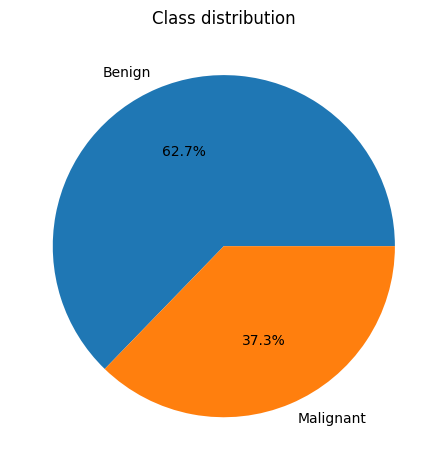

In [38]:
counts = y.value_counts().sort_index()
counts.index = ["Benign", "Malignant"]

ax = counts.plot.pie(
    autopct="%1.1f%%",
    ylabel="",
    title="Class distribution",
)

plt.tight_layout()
plt.show()

# Datan jakaminen 

Jakaminen toteutetaan 75 / 25 (opetusdata / testidata) 

In [39]:

training, test = train_test_split(
    df,
    train_size=TRAINING_DATA_SIZE,
    random_state=RANDOM_SEED,
    stratify=df["malignant"],
)

DATA_PATH.mkdir(parents=True, exist_ok=True)

training.to_csv(TRAINING_PATH, index=False)
test.to_csv(TEST_PATH, index=False)

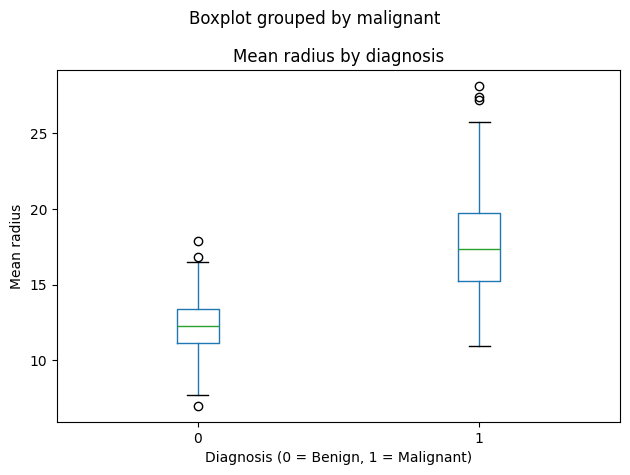

In [40]:
ax = training.boxplot(
    column="mean radius",
    by="malignant",
    grid=False,
)

ax.set(
    title="Mean radius by diagnosis",
    xlabel="Diagnosis (0 = Benign, 1 = Malignant)",
    ylabel="Mean radius",
)


plt.tight_layout()
plt.show()

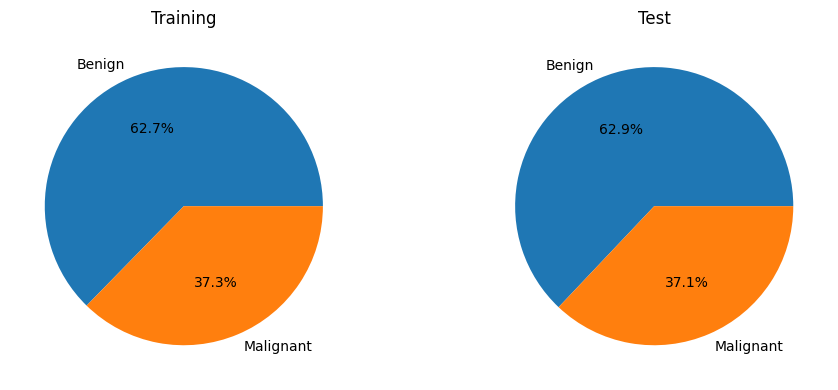

In [41]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, data) in zip(
    axes,
    [("Training", training), ("Test", test)]
):
    counts = data["malignant"].value_counts().sort_index()
    counts.index = ["Benign", "Malignant"]

    counts.plot.pie(
        ax=ax,
        autopct="%1.1f%%",
        ylabel="",
        title=name,
    )

plt.tight_layout()
plt.show()


## Muutujien välinen korrelaatio 

In [42]:
# Calculate correlations between features
X_train = training.drop(columns="malignant")
correlation = X_train.corr()

# Keep only unique feature pairs
upper = correlation.where(
    np.triu(np.ones(correlation.shape), k=1).astype(bool)
)

pairs = upper.stack().reset_index()
pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

# Sort by absolute correlation
pairs["Absolute correlation"] = pairs["Correlation"].abs()

strong_pairs = pairs[
    pairs["Absolute correlation"] >= CORRELATION_THRESHOLD
].sort_values("Absolute correlation", ascending=False)

display(strong_pairs)

,Feature 1,Feature 2,Correlation,Absolute correlation
1,mean radius,mean perimeter,0.997836,0.997836
391,worst radius,worst perimeter,0.993823,0.993823
2,mean radius,mean area,0.986418,0.986418
57,mean perimeter,mean area,0.985747,0.985747
392,worst radius,worst area,0.982700,0.982700
246,radius error,perimeter error,0.978848,0.978848
407,worst perimeter,worst area,0.976588,0.976588
74,mean perimeter,worst radius,0.969975,0.969975
76,mean perimeter,worst perimeter,0.969523,0.969523
19,mean radius,worst radius,0.969508,0.969508


# Korrelaation tulosten analyysi
Korrelaatioanalyysissä havaittiin, että erityisesti solutuman kokoa kuvaavat muuttujat (radius, perimeter ja area) korreloivat voimakkaasti keskenään. Myös useat samaa ominaisuutta kuvaavat mean- ja worst-muuttujat korreloivat voimakkaasti, mikä oli odotettavissa.

Nämä korrelaatiot voivat aiheuttaa multikollineaarisuutta ja vaikeuttaa logistisen regression kertoimien tulkintaa. Muuttujia ei kuitenkaan vielä poisteta, vaan seuraavassa vaiheessa tutkitaan muuttujavalinnan vaikutusta mallin ennustekykyyn.